In [1]:
import os
import re
import gc
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
import joblib
from gensim.models import Word2Vec
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense, Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam


warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

print("Semua library berhasil diimport.")
print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1780639896.534828   66729 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Semua library berhasil diimport.
TensorFlow version: 2.21.0


In [2]:
DATA_PATH = "data/dataset-shopee-20.csv"

try:
    df = pd.read_csv(DATA_PATH)
    print(f"Jumlah data awal: {len(df)}")
    print(f"Kolom yang tersedia: {list(df.columns)}")
    print("\nDistribusi rating awal:")
    print(df["rating"].value_counts().sort_index())
except FileNotFoundError:
    print("ERROR: File dataset tidak ditemukan. Pastikan path benar.")

Jumlah data awal: 20000
Kolom yang tersedia: ['app_id', 'app_name', 'review_id', 'review_text', 'rating', 'review_date', 'scraped_at']

Distribusi rating awal:
rating
1    7056
2    1669
3    1599
4    1340
5    8336
Name: count, dtype: int64


In [3]:
# KAMUS SLANG INDONESIA
SLANG_DICT = {
    'yg': 'yang', 'gk': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'ga': 'tidak',
    'ngga': 'tidak', 'bgt': 'banget', 'bangett': 'banget', 'bgd': 'banget',
    'dgn': 'dengan', 'dr': 'dari', 'krn': 'karena', 'karna': 'karena', 'utk': 'untuk',
    'thd': 'terhadap', 'sdh': 'sudah', 'blm': 'belum', 'jgn': 'jangan', 'tp': 'tapi',
    'cm': 'cuma', 'cuman': 'cuma', 'aja': 'saja', 'doang': 'saja', 'bsa': 'bisa',
    'bngt': 'banget', 'apk': 'aplikasi', 'app': 'aplikasi',
    'mantap': 'bagus', 'keren': 'bagus', 'jelek': 'buruk', 'rusak': 'buruk',
    'lemot': 'lambat', 'lelet': 'lambat', 'parah': 'buruk', 'nyesel': 'kecewa',
    'kecewa': 'kecewa', 'marah': 'marah', 'kesal': 'kesal', 'kurir': 'kurir',
    'paket': 'paket', 'barang': 'barang', 'order': 'pesanan', 'pesanan': 'pesanan',
    'belanja': 'belanja', 'beli': 'beli', 'murah': 'murah', 'mahal': 'mahal',
    'diskon': 'diskon', 'gratis': 'gratis', 'ongkir': 'ongkos kirim',
    'sampai': 'sampai', 'kirim': 'kirim', 'puas': 'puas', 'suka': 'suka',
    'bagus': 'bagus', 'baik': 'baik', 'ramah': 'ramah', 'cepat': 'cepat',
    'lancar': 'lancar', 'mudah': 'mudah', 'ribet': 'sulit', 'susah': 'sulit',
    'error': 'error', 'bug': 'error', 'crash': 'error', 'gangguan': 'error',
    'refund': 'refund', 'return': 'return', 'asli': 'asli', 'palsu': 'palsu',
    'kw': 'palsu', 'tipu': 'tipu', 'penipu': 'tipu', 'scam': 'tipu',
    'aman': 'aman', 'terpercaya': 'terpercaya', 'recommended': 'rekomendasi'
}

def normalize_slang(text: str) -> str:
    words = text.split()
    return ' '.join([SLANG_DICT.get(w, w) for w in words])

def clean_text_improved(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    # Pertahankan tanda seru dan tanya untuk konteks sentimen
    text = re.sub(r'[^\w\s!?]', ' ', text)
    text = normalize_slang(text)
    return re.sub(r'\s+', ' ', text).strip()

print("Melakukan preprocessing teks...")
start_time = time.time()
df["clean_text"] = df["review_text"].apply(clean_text_improved)
df = df[df["clean_text"].str.len() > 3].reset_index(drop=True)

print(f"Preprocessing selesai dalam {time.time() - start_time:.2f} detik")
print(f"Jumlah data setelah cleaning: {len(df)}")
gc.collect()

Melakukan preprocessing teks...
Preprocessing selesai dalam 0.34 detik
Jumlah data setelah cleaning: 20000


0

In [4]:
# PELABELAN KELAS
def map_rating_to_sentiment_class(rating) -> str:
    try:
        r = float(rating)
        if r <= 2.0:
            return "negatif"
        elif r >= 4.0:
            return "positif"
        else:
            return None
    except Exception:
        return None

print("Melakukan pelabelan sentimen...")
df["sentiment"] = df["rating"].apply(map_rating_to_sentiment_class)

before_drop = len(df)
df = df.dropna(subset=["sentiment"]).reset_index(drop=True)
after_drop = len(df)

print(f"Data yang dibuang: {before_drop - after_drop}")
print(f"Data tersisa: {after_drop}")

print("\nDistribusi kelas sebelum balancing:")
print(df["sentiment"].value_counts())

# CLASS BALANCING AMAN
min_count = df['sentiment'].value_counts().min()
target_per_class = min(min_count, 5000)

print(f"\nTarget pengambilan per kelas: {target_per_class}")

df_balanced = pd.DataFrame()
for sentiment_class in df['sentiment'].unique():
    df_class = df[df['sentiment'] == sentiment_class].sample(
        n=target_per_class, random_state=42
    )
    df_balanced = pd.concat([df_balanced, df_class])

df = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nDistribusi kelas setelah balancing (Total: {len(df)} data):")
print(df["sentiment"].value_counts())

if len(df) < 10000:
    print("PERINGATAN: Total data di bawah 10.000. Saran penilaian Rating 5 tidak terpenuhi.")
else:
    print("Dataset memenuhi syarat minimal 10.000 sampel.")

Melakukan pelabelan sentimen...
Data yang dibuang: 1599
Data tersisa: 18401

Distribusi kelas sebelum balancing:
sentiment
positif    9676
negatif    8725
Name: count, dtype: int64

Target pengambilan per kelas: 5000

Distribusi kelas setelah balancing (Total: 10000 data):
sentiment
positif    5000
negatif    5000
Name: count, dtype: int64
Dataset memenuhi syarat minimal 10.000 sampel.


In [5]:
# PERSIAPAN DATA
X = df["clean_text"]
y = df["sentiment"]

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

print(f"Kelas yang terdeteksi: {class_names}")

# Pembagian data 80/20 untuk Skema 1 dan 2
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Pembagian data 70/30 untuk Skema 3
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"\nUkuran data training (80/20): {len(X_train_80)} train, {len(X_test_80)} test")
print(f"Ukuran data training (70/30): {len(X_train_70)} train, {len(X_test_70)} test")

Kelas yang terdeteksi: ['negatif' 'positif']

Ukuran data training (80/20): 8000 train, 2000 test
Ukuran data training (70/30): 7000 train, 3000 test


In [6]:
# SKEMA 1: LinearSVC + TF-IDF (80/20)
print("SKEMA 1: LinearSVC + TF-IDF (Pembagian Data 80/20)")
start = time.time()

tfidf = TfidfVectorizer(
    max_features=20000, ngram_range=(1, 2), min_df=3, max_df=0.95, sublinear_tf=True
)

print("Mengekstrak fitur TF-IDF...")
X_train_tfidf = tfidf.fit_transform(X_train_80)
X_test_tfidf = tfidf.transform(X_test_80)

print("Melatih model LinearSVC...")
model_svc = LinearSVC(
    C=2.0, class_weight="balanced", max_iter=10000, dual=False, tol=1e-4
)
model_svc.fit(X_train_tfidf, y_train_80)

y_pred_svc = model_svc.predict(X_test_tfidf)
acc_svc = accuracy_score(y_test_80, y_pred_svc)

print(f"\nAkurasi Testing: {acc_svc:.4f} ({acc_svc*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test_80, y_pred_svc, target_names=class_names))
print(f"Waktu pelatihan: {time.time() - start:.2f} detik")
gc.collect()

SKEMA 1: LinearSVC + TF-IDF (Pembagian Data 80/20)
Mengekstrak fitur TF-IDF...
Melatih model LinearSVC...

Akurasi Testing: 0.8715 (87.15%)

Classification Report:
              precision    recall  f1-score   support

     negatif       0.86      0.89      0.87      1000
     positif       0.88      0.86      0.87      1000

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000

Waktu pelatihan: 0.76 detik


2

In [7]:
# SKEMA 2: Logistic Regression + Word2Vec (80/20)
print("SKEMA 2: Logistic Regression + Word2Vec (Pembagian Data 80/20)")
start = time.time()

print("Membangun model Word2Vec...")
tokenized_train = [doc.split() for doc in X_train_80]
w2v_model = Word2Vec(
    sentences=tokenized_train, vector_size=150, window=5, min_count=2, workers=8, epochs=15
)

def document_vector(doc: str, model, size: int = 150) -> np.ndarray:
    words = doc.split()
    valid_vecs = [model.wv[w] for w in words if w in model.wv]
    return np.mean(valid_vecs, axis=0) if valid_vecs else np.zeros(size)

print("Mengekstrak fitur Word2Vec...")
X_train_w2v = np.array([document_vector(doc, w2v_model, size=150) for doc in X_train_80])
X_test_w2v = np.array([document_vector(doc, w2v_model, size=150) for doc in X_test_80])

print("Melatih model Logistic Regression...")
model_lr = LogisticRegression(
    C=10.0,
    max_iter=1000,
    class_weight="balanced",
    solver='lbfgs',
    n_jobs=-1,
    random_state=42
)
model_lr.fit(X_train_w2v, y_train_80)

y_pred_lr = model_lr.predict(X_test_w2v)
acc_lr = accuracy_score(y_test_80, y_pred_lr)

print(f"\nAkurasi Testing: {acc_lr:.4f} ({acc_lr*100:.2f}%)")
print(f"\nClassification Report:")
print(classification_report(y_test_80, y_pred_lr, target_names=class_names))
print(f"Waktu pelatihan: {time.time() - start:.2f} detik")
gc.collect()

SKEMA 2: Logistic Regression + Word2Vec (Pembagian Data 80/20)
Membangun model Word2Vec...
Mengekstrak fitur Word2Vec...
Melatih model Logistic Regression...

Akurasi Testing: 0.8505 (85.05%)

Classification Report:
              precision    recall  f1-score   support

     negatif       0.83      0.89      0.86      1000
     positif       0.88      0.82      0.85      1000

    accuracy                           0.85      2000
   macro avg       0.85      0.85      0.85      2000
weighted avg       0.85      0.85      0.85      2000

Waktu pelatihan: 4.86 detik


0

In [8]:
# SKEMA 3: BiLSTM + Embedding (70/30)
print("SKEMA 3: BiLSTM + Embedding (Pembagian Data 70/30)")
start = time.time()

MAX_WORDS = 25000
MAX_LEN = 128
EMBEDDING_DIM = 128
BATCH_SIZE = 64
EPOCHS = 20

print("Membangun tokenizer...")
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_70)

print("Melakukan padding sequences...")
X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train_70), maxlen=MAX_LEN, padding="post", truncating="post")
X_test_seq = pad_sequences(tokenizer.texts_to_sequences(X_test_70), maxlen=MAX_LEN, padding="post", truncating="post")

# Hitung class_weight untuk menangani ketidakseimbangan kelas saat training BiLSTM
class_weights_list = class_weight.compute_class_weight(
    'balanced', classes=np.unique(y_train_70), y=y_train_70
)
class_weight_dict = {i: class_weights_list[i] for i in range(len(class_weights_list))}

print("Membangun arsitektur BiLSTM...")
model_lstm = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    SpatialDropout1D(0.2),
    Bidirectional(LSTM(128, return_sequences=True)),
    Bidirectional(LSTM(64)),
    Dense(64, activation="relu"),
    Dropout(0.4),
    Dense(len(class_names), activation="softmax")
])

model_lstm.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1)

print("\nMelatih model BiLSTM...")
history = model_lstm.fit(
    X_train_seq, y_train_70,
    validation_split=0.15,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

loss, acc_lstm = model_lstm.evaluate(X_test_seq, y_test_70, verbose=0)
print(f"\nAkurasi Testing: {acc_lstm:.4f} ({acc_lstm*100:.2f}%)")
print(f"Waktu pelatihan: {time.time() - start:.2f} detik")
gc.collect()

SKEMA 3: BiLSTM + Embedding (Pembagian Data 70/30)
Membangun tokenizer...
Melakukan padding sequences...
Membangun arsitektur BiLSTM...

Melatih model BiLSTM...
Epoch 1/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 29s 270ms/step - accuracy: 0.7862 - loss: 0.4505 - val_accuracy: 0.8581 - val_loss: 0.3380 - learning_rate: 0.0010
Epoch 2/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 27s 286ms/step - accuracy: 0.9039 - loss: 0.2540 - val_accuracy: 0.8648 - val_loss: 0.3278 - learning_rate: 0.0010
Epoch 3/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 25s 268ms/step - accuracy: 0.9425 - loss: 0.1711 - val_accuracy: 0.8486 - val_loss: 0.3982 - learning_rate: 0.0010
Epoch 4/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.9700 - loss: 0.0977
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
93/93 ━━━━━━━━━━━━━━━━━━━━ 25s 264ms/step - accuracy: 0.9696 - loss: 0.0943 - val_accuracy: 0.8286 - val_loss: 0.5224 - learning_rate: 0.0010
Epoch 5/20
93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 229ms/step - accuracy: 0.9827 - lo

3946

PERBANDINGAN HASIL 3 SKEMA PELATIHAN


,Skema,Algoritma,Ekstraksi Fitur,Pembagian Data,Akurasi_Test
0,SVC + TF-IDF (80/20),LinearSVC,TF-IDF,80/20,0.871500
1,LR + Word2Vec (80/20),Logistic Regression,Word2Vec,80/20,0.850500
2,BiLSTM + Embedding (70/30),BiLSTM (Deep Learning),Embedding Layer,70/30,0.866667



Skema: SVC + TF-IDF (80/20)
Algoritma: LinearSVC
Akurasi: 0.8715 (87.15%)


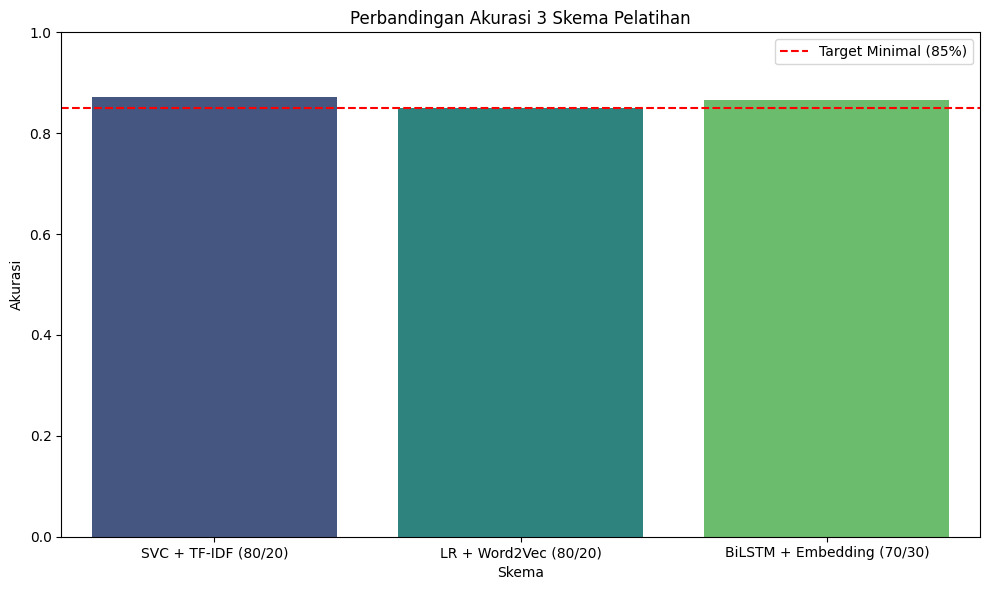


Menyimpan model dan artifacts...
Semua model dan artifacts berhasil disimpan.


In [9]:
artifact_dir = "artifacts"
os.makedirs(artifact_dir, exist_ok=True)

results = pd.DataFrame({
    "Skema": ["SVC + TF-IDF (80/20)", "LR + Word2Vec (80/20)", "BiLSTM + Embedding (70/30)"],
    "Algoritma": ["LinearSVC", "Logistic Regression", "BiLSTM (Deep Learning)"],
    "Ekstraksi Fitur": ["TF-IDF", "Word2Vec", "Embedding Layer"],
    "Pembagian Data": ["80/20", "80/20", "70/30"],
    "Akurasi_Test": [acc_svc, acc_lr, acc_lstm]
})

print("PERBANDINGAN HASIL 3 SKEMA PELATIHAN")
display(results)

best_idx = results["Akurasi_Test"].idxmax()
print(f"\nSkema: {results.loc[best_idx, 'Skema']}")
print(f"Algoritma: {results.loc[best_idx, 'Algoritma']}")
print(f"Akurasi: {results.loc[best_idx, 'Akurasi_Test']:.4f} ({results.loc[best_idx, 'Akurasi_Test']*100:.2f}%)")

plt.figure(figsize=(10, 6))
sns.barplot(data=results, x="Skema", y="Akurasi_Test", palette="viridis")
plt.axhline(y=0.85, color='r', linestyle='--', label='Target Minimal (85%)')
plt.ylabel("Akurasi")
plt.title("Perbandingan Akurasi 3 Skema Pelatihan")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(artifact_dir, "grafik_perbandingan_akurasi.png"))
plt.show()

# SIMPAN MODEL & ARTIFACTS
print("\nMenyimpan model dan artifacts...")

results.to_csv(os.path.join(artifact_dir, "hasil_evaluasi.csv"), index=False)

joblib.dump(tfidf, os.path.join(artifact_dir, "tfidf_vectorizer.pkl"))
joblib.dump(model_svc, os.path.join(artifact_dir, "model_svc.pkl"))
joblib.dump(model_lr, os.path.join(artifact_dir, "model_lr.pkl"))
joblib.dump(w2v_model, os.path.join(artifact_dir, "w2v_model.pkl"))
joblib.dump(le, os.path.join(artifact_dir, "label_encoder.pkl"))

with open(os.path.join(artifact_dir, "tokenizer.json"), "w", encoding="utf-8") as f:
    f.write(tokenizer.to_json())

model_lstm.save(os.path.join(artifact_dir, "model_bilstm.keras"))
print("Semua model dan artifacts berhasil disimpan.")

In [10]:
# TESTING
def predict_sentiment(texts: list, model_type: str = "svc") -> list:
    cleaned = [clean_text_improved(t) for t in texts]

    if model_type == "svc":
        tfidf_loaded = joblib.load("tfidf_vectorizer.pkl")
        model_loaded = joblib.load("model_svc.pkl")
        X_inf = tfidf_loaded.transform(cleaned)
        preds = model_loaded.predict(X_inf)

    elif model_type == "lr":
        w2v_loaded = joblib.load("w2v_model.pkl")
        model_loaded = joblib.load("model_lr.pkl")
        X_inf = np.array([document_vector(doc, w2v_loaded, size=150) for doc in cleaned])
        preds = model_loaded.predict(X_inf)

    elif model_type == "bilstm":
        from tensorflow.keras.models import load_model
        from tensorflow.keras.preprocessing.text import tokenizer_from_json

        with open("tokenizer.json", "r", encoding="utf-8") as f:
            tok = tokenizer_from_json(f.read())

        model_loaded = load_model("model_bilstm.keras")
        seq = pad_sequences(tok.texts_to_sequences(cleaned), maxlen=MAX_LEN, padding="post", truncating="post")
        preds_proba = model_loaded.predict(seq, verbose=0)
        preds = np.argmax(preds_proba, axis=1)
    else:
        raise ValueError("Model type tidak didukung.")

    le_loaded = joblib.load("label_encoder.pkl")
    return le_loaded.inverse_transform(preds)

# INFERENCE
print("HASIL INFERENCE")

best_algo = results.loc[best_idx, "Algoritma"].lower()
if "svc" in best_algo:
    best_model_type = "svc"
elif "lr" in best_algo:
    best_model_type = "lr"
else:
    best_model_type = "bilstm"

print(f"Menggunakan model: {best_model_type.upper()}\n")

sample_reviews = [
    "Aplikasi sangat bagus, pengiriman cepat dan kurir ramah. Puas banget belanja di sini!",
    "Sering error, login susah, banyak bug. Kecewa berat, tidak recommended.",
    "Barang oke tapi pengiriman lama, agak kecewa sih tapi bisa dimaklumi.",
    "Biasa saja, tidak ada yang spesial tapi cukup berfungsi untuk belanja sehari-hari.",
    "Penipu! Barang tidak sampai, refund tidak diproses. Hati-hati belanja di sini."
]

predictions = predict_sentiment(sample_reviews, model_type=best_model_type)

print("Hasil Prediksi Sentimen:")

for i, (review, sentiment) in enumerate(zip(sample_reviews, predictions), 1):
    print(f"{i}. Teks: {review[:80]}...")
    print(f"   Prediksi: {sentiment.upper()}")
    print()

HASIL INFERENCE
Menggunakan model: SVC



FileNotFoundError: [Errno 2] No such file or directory: 'tfidf_vectorizer.pkl'